In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("retail_sales_dataset.csv")
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [3]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [5]:
print("The number of records in the data is:",df.shape[0])
print("The number of records in the data is:",df.shape[1])


The number of records in the data is: 1000
The number of records in the data is: 9


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [7]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [8]:
df.describe(include= "O")

,Date,Customer ID,Gender,Product Category
count,1000,1000,1000,1000
unique,345,1000,2,3
top,2023-05-16,CUST001,Female,Clothing
freq,11,1,510,351


#### pandas will look only at the columns whose datatype is "O" (object). Then it provides summary stats such as:
##### count – Number of non-missing values
##### unique – How many distinct values the column has
##### top – The most frequent value
##### freq – The frequency of that most frequent value

In [9]:
# check for inconsistent values
for i in df.columns:
    if df[i].nunique() != len(df[i]):
        print(i)
        print(df[i].unique())
        print("-"*100)
        print()


Date
['2023-11-24' '2023-02-27' '2023-01-13' '2023-05-21' '2023-05-06'
 '2023-04-25' '2023-03-13' '2023-02-22' '2023-12-13' '2023-10-07'
 '2023-02-14' '2023-10-30' '2023-08-05' '2023-01-17' '2023-01-16'
 '2023-02-17' '2023-04-22' '2023-04-30' '2023-09-16' '2023-11-05'
 '2023-01-14' '2023-10-15' '2023-04-12' '2023-11-29' '2023-12-26'
 '2023-08-03' '2023-04-23' '2023-08-18' '2023-10-29' '2023-05-23'
 '2023-01-04' '2023-03-23' '2023-12-24' '2023-06-24' '2023-03-21'
 '2023-04-21' '2023-06-22' '2023-07-14' '2023-02-19' '2023-07-03'
 '2023-06-26' '2023-11-06' '2023-05-16' '2023-01-23' '2023-08-24'
 '2023-10-02' '2023-03-05' '2023-07-13' '2023-02-10' '2023-10-10'
 '2023-05-31' '2023-11-18' '2023-11-13' '2023-07-05' '2023-10-23'
 '2023-04-09' '2023-12-27' '2023-02-05' '2023-01-24' '2023-12-05'
 '2023-04-27' '2023-05-29' '2023-02-21' '2023-08-21' '2023-11-22'
 '2023-07-06' '2023-03-25' '2023-07-09' '2023-07-01' '2023-04-18'
 '2023-12-10' '2023-05-17' '2023-12-16' '2023-11-28' '2023-02-06'
 '202

In [10]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df['Date']= pd.to_datetime(df['Date'])

df['Month']=df['Date'].dt.month_name()
df['Year']=df['Date'].dt.year
df['Days']=df['Date'].dt.day_name()
df['MonthDate']=df['Date'].dt.day
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Year,Days,MonthDate
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,2023,Friday,24
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,2023,Monday,27
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,January,2023,Friday,13
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,2023,Sunday,21
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,2023,Saturday,6


In [13]:
bins=[18,30,40,50,60,70]
label = ['18-29','30-39','40-49','50-59','60+']
df['age_group'] = pd.cut(df['Age'],labels=label,bins=bins)
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Year,Days,MonthDate,age_group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,2023,Friday,24,30-39
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,2023,Monday,27,18-29
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,January,2023,Friday,13,40-49
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,2023,Sunday,21,30-39
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,2023,Saturday,6,18-29


### Analyze the relationship between age,gender,and spending behaviour.

### Compare average the relationship betweeen age , gender and spending behaviour

In [14]:
# df.reset_index()
spending_summary = df.groupby(['age_group', 'Gender'], observed=True)["Total Amount"].agg(['mean']).reset_index()
print(spending_summary)

  age_group  Gender        mean
0     18-29  Female  491.031746
1     18-29    Male  475.079365
2     30-39  Female  521.546392
3     30-39    Male  472.500000
4     40-49  Female  387.715517
5     40-49    Male  464.952381
6     50-59  Female  465.818966
7     50-59    Male  442.788462
8       60+  Female  319.761905
9       60+    Male  388.137255


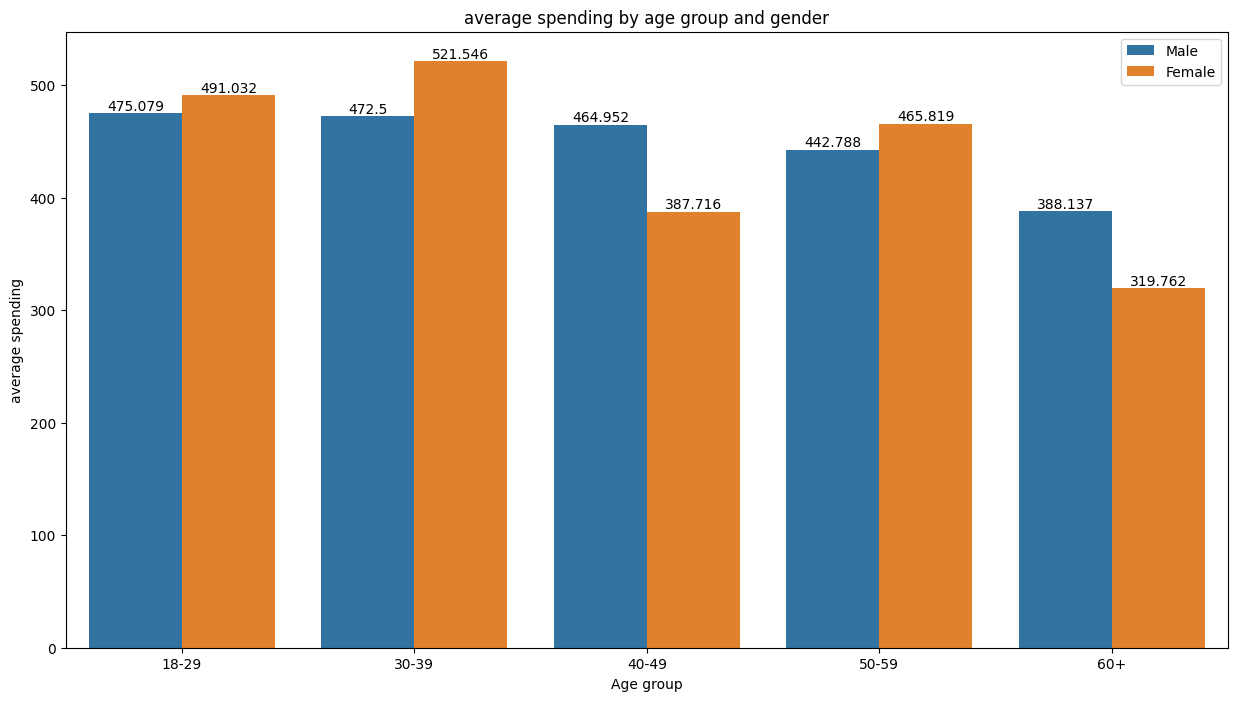

In [15]:
plt.figure(figsize=(15,8))
k=sns.barplot(data=df,x='age_group',y='Total Amount',hue='Gender',errorbar=None)

k.bar_label(k.containers[0])
k.bar_label(k.containers[1])

plt.title('average spending by age group and gender')
plt.xlabel('Age group')
plt.ylabel('average spending')
plt.legend()
plt.show()
              

              

### Identify trends in sales over different months, seasons, and years

In [16]:
month_order= ['january','February','March','April','May','June','July','Agust','September','October','November','December']

#convert the month 
df['Month']=pd.Categorical(df['Month'],categories=month_order,ordered=True)
df['Month']

0      November
1      February
2           NaN
3           May
4           May
         ...   
995         May
996    November
997     October
998    December
999       April
Name: Month, Length: 1000, dtype: category
Categories (12, object): ['january' < 'February' < 'March' < 'April' ... 'September' < 'October' < 'November' < 'December']

#### The .map() function reads each value in the "Month" column and replaces it with a corresponding valuee from the dictionary you provided.

In [17]:
day_order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['Days']=pd.Categorical(df['Days'],categories=day_order,ordered=True)
df['Days']

0         Friday
1         Monday
2         Friday
3         Sunday
4       Saturday
         ...    
995      Tuesday
996       Friday
997       Sunday
998      Tuesday
999    Wednesday
Name: Days, Length: 1000, dtype: category
Categories (7, object): ['Monday' < 'Tuesday' < 'Wednesday' < 'Thursday' < 'Friday' < 'Saturday' < 'Sunday']

In [18]:
df['Season'] = df['Month'].map({
    'December': 'Winter', 'January': 'Winter', 'February': 'Winter',
    "March": 'Summer', "April": 'Summer', "May": 'Summer',
    "June": 'Monsoon', "July":'Monsoon', "August": 'Monsoon',
    "September": 'Monsoon', "October": 'Post-Monsoon', "November": 'Post-Monsoon'
})
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Year,Days,MonthDate,age_group,Season
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,2023,Friday,24,30-39,Post-Monsoon
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,2023,Monday,27,18-29,Winter
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,NaN,2023,Friday,13,40-49,NaN
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,2023,Sunday,21,30-39,Summer
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,2023,Saturday,6,18-29,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,May,2023,Tuesday,16,60+,Summer
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,November,2023,Friday,17,50-59,Post-Monsoon
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,October,2023,Sunday,29,18-29,Post-Monsoon
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,December,2023,Tuesday,5,30-39,Winter


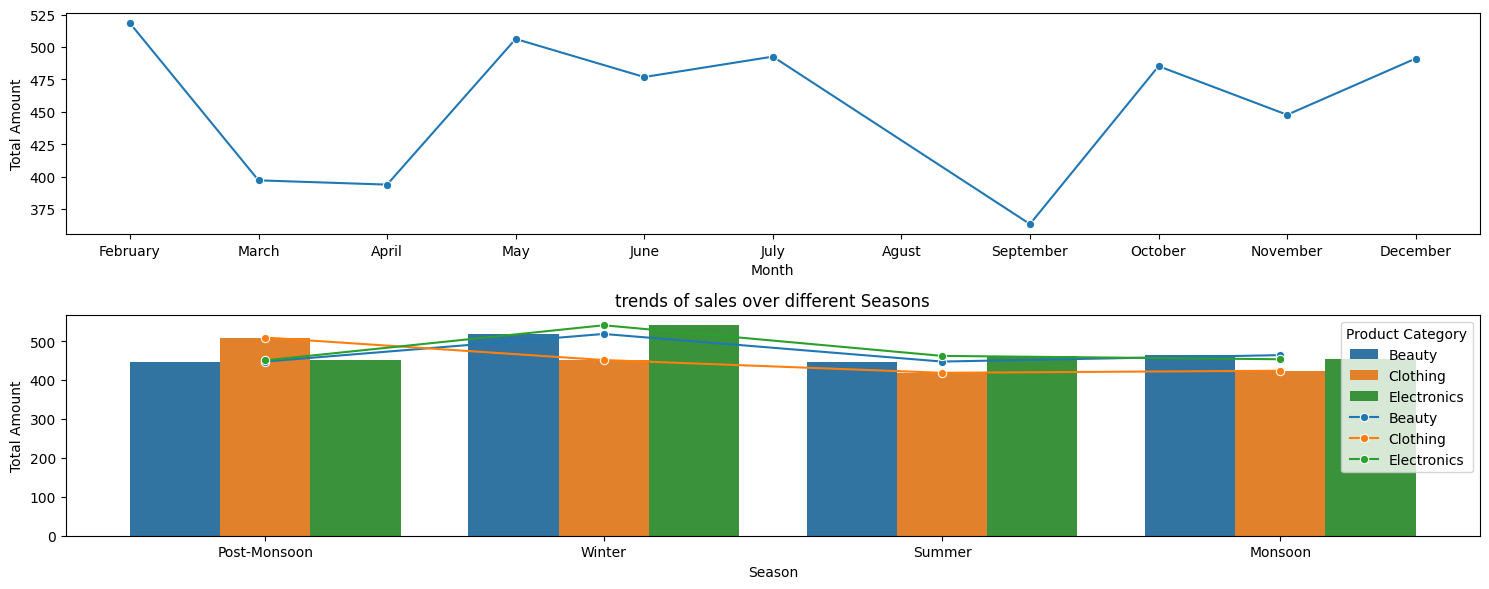

In [19]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(15, 6))

sns.lineplot(data = df, x= "Month", y="Total Amount",marker="o", errorbar=None,ax=axes[0] )
plt.title("trends of sales over different months")

b=sns.barplot(data = df, x = 'Season' , y = 'Total Amount' , hue= 'Product Category',errorbar=None)
#b.bar_label(b.containers[0])
#b.bar_label(b.containers[1])
#b.bar_label(b.containers[2])


sns.lineplot(data = df, x= "Season", y="Total Amount", hue= 'Product Category',marker="o", errorbar=None, ax=axes[1])
plt.title("trends of sales over different Seasons")

plt.tight_layout()
plt.show()

### Top product categories by revenue


In [20]:
if 'Revenue' not in df.columns:
    df['Revenue'] = df['Quantity']*df['Price per Unit']

revenue = df.groupby('Product Category')['Revenue'].sum().reset_index()
revenue

,Product Category,Revenue
0,Beauty,143515
1,Clothing,155580
2,Electronics,156905


In [21]:
revenue= revenue.sort_values(by='Revenue', ascending = False)
revenue

,Product Category,Revenue
2,Electronics,156905
1,Clothing,155580
0,Beauty,143515


C:\Users\Sakshi Gangawane\AppData\Local\Temp\ipykernel_1216\1599368631.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


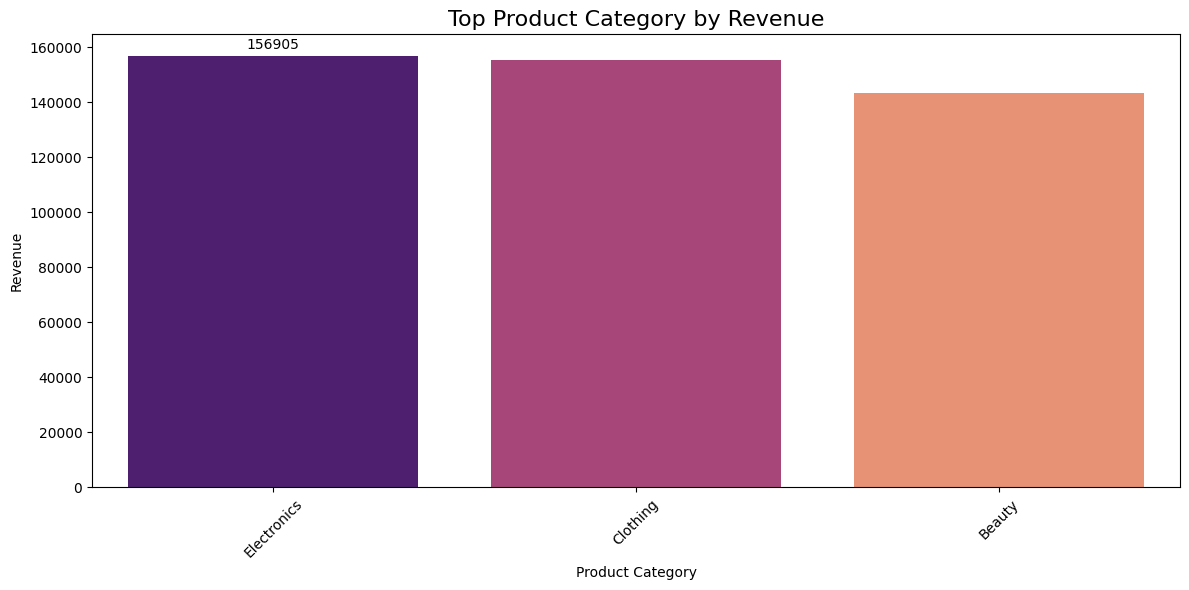

In [22]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=revenue,
    x='Product Category',
    y='Revenue',
    palette='magma',
    legend=False
)

ax.bar_label(ax.containers[0], padding=3)

plt.title("Top Product Category by Revenue", fontsize=16)
plt.xticks(rotation=45)
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

           

### Analyaze customer demographics for each product category

#### Gender Distribution per Product Category

In [23]:
gender_dist= df.groupby(['Product Category', 'Gender']).size().unstack()
print(gender_dist)

Gender            Female  Male
Product Category              
Beauty               166   141
Clothing             174   177
Electronics          170   172


#### unstack() is used when you group by more than one column and want to convert one of those grouping levels into columns instead of keeping everything in a long format.
##### groupby() → produces stacked multi-index output
##### unstack() → converts it into a pivot-table-like structure

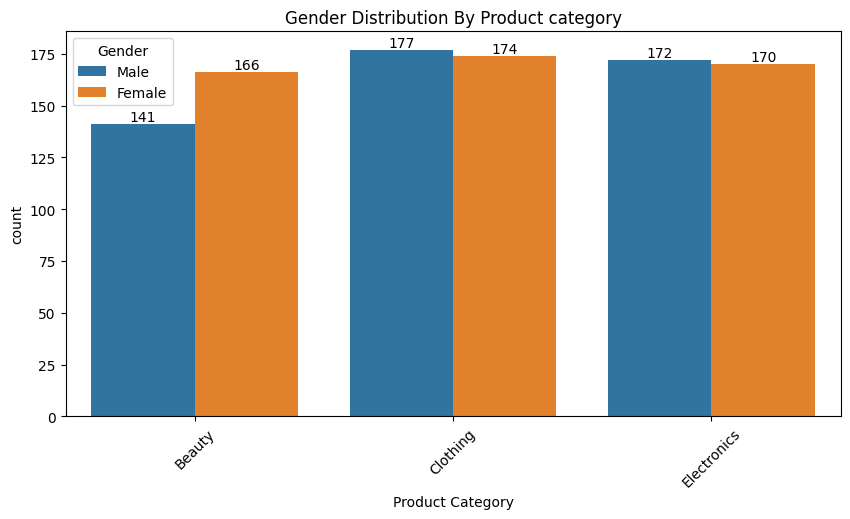

In [24]:
plt.figure(figsize=(10,5))
b=sns.countplot(data=df, x='Product Category', hue='Gender')
b.bar_label(b.containers[0])
b.bar_label(b.containers[1])
plt.title('Gender Distribution By Product category')
plt.xticks(rotation=45)
plt.show()

### B.Age Group Distribution per product Category

In [25]:
age_group_dist = df.groupby(['Product Category', 'age_group']).size().unstack()
print(age_group_dist)


age_group         18-29  30-39  40-49  50-59  60+
Product Category                                 
Beauty               88     56     66     62   26
Clothing             81     69     81     80   33
Electronics          83     68     74     78   34


C:\Users\Sakshi Gangawane\AppData\Local\Temp\ipykernel_1216\2306420595.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_dist = df.groupby(['Product Category', 'age_group']).size().unstack()


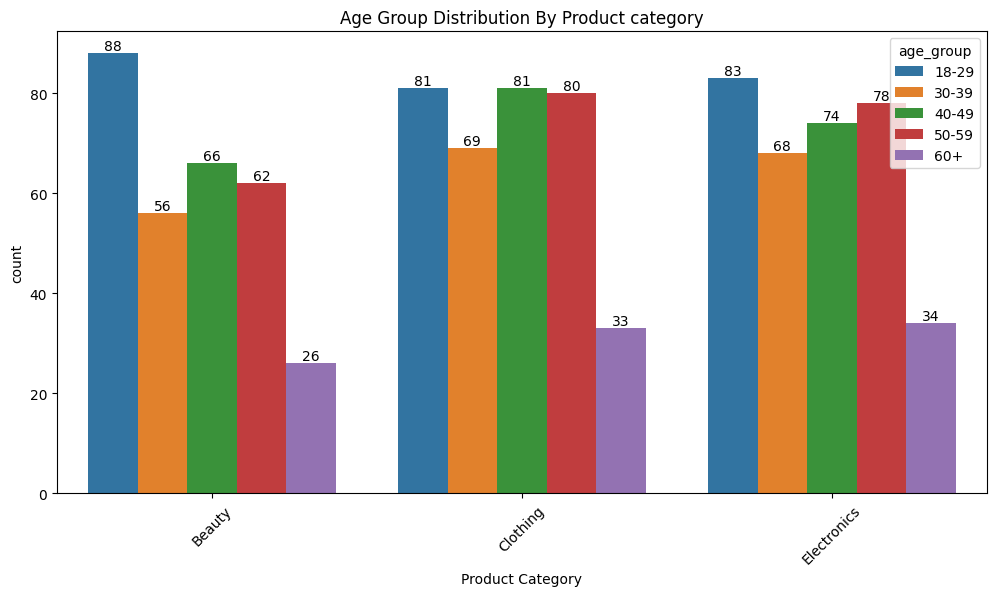

In [26]:
plt.figure(figsize=(12,6))
k=sns.countplot(data=df,x="Product Category", hue='age_group')

for i in k.containers:
    k.bar_label(i)

plt.title('Age Group Distribution By Product category')
plt.xticks(rotation=45)
plt.show()

### C.Average Age of Customer by category

In [27]:
avg_age= df.groupby('Product Category')['Age'].mean()
print(avg_age)

Product Category
Beauty         40.371336
Clothing       41.948718
Electronics    41.736842
Name: Age, dtype: float64


### Final summary

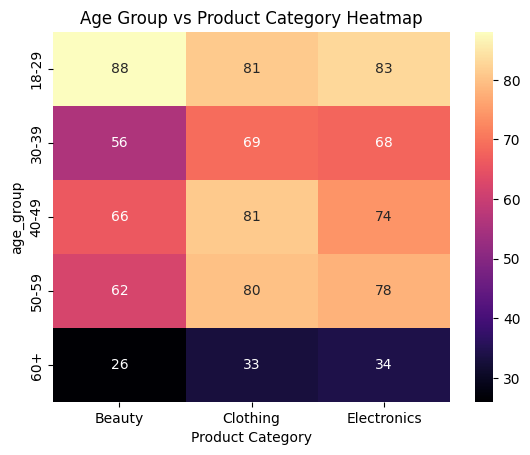

In [28]:
# Age Group vs Product category Heatmap
pivot = df.pivot_table(
    values='Customer ID',
    index='age_group',
    columns='Product Category',
    aggfunc='count',
    observed=False
)

sns.heatmap(pivot,annot=True, cmap='magma')
plt.title("Age Group vs Product Category Heatmap")
plt.show()

### Study correlations between age ,total spending,and product choices


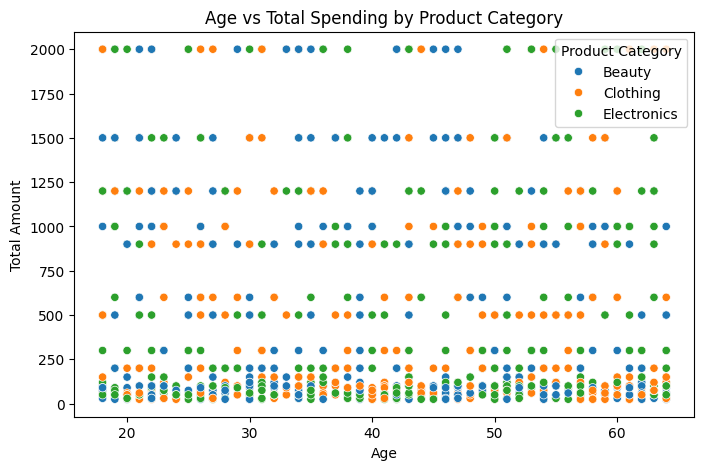

In [29]:
df
plt.figure(figsize =(8,5))

sns.scatterplot(data = df,x = 'Age' ,y='Total Amount',hue="Product Category")
plt.title("Age vs Total Spending by Product Category")
plt.show()                

### Conclusion 

### Conclusion From the Graph
#### No strong direct correlation between Age and Total Spending

#### The points are scattered across all ages (18–65) without forming an upward or downward trend. This means age alone does not significantly determine how much a customer spends.

In [30]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount',
       'Month', 'Year', 'Days', 'MonthDate', 'age_group', 'Season', 'Revenue'],
      dtype='object')

C:\Users\Sakshi Gangawane\AppData\Local\Temp\ipykernel_1216\1853799427.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data=df, x="Season", y="Quantity", estimator=sum,


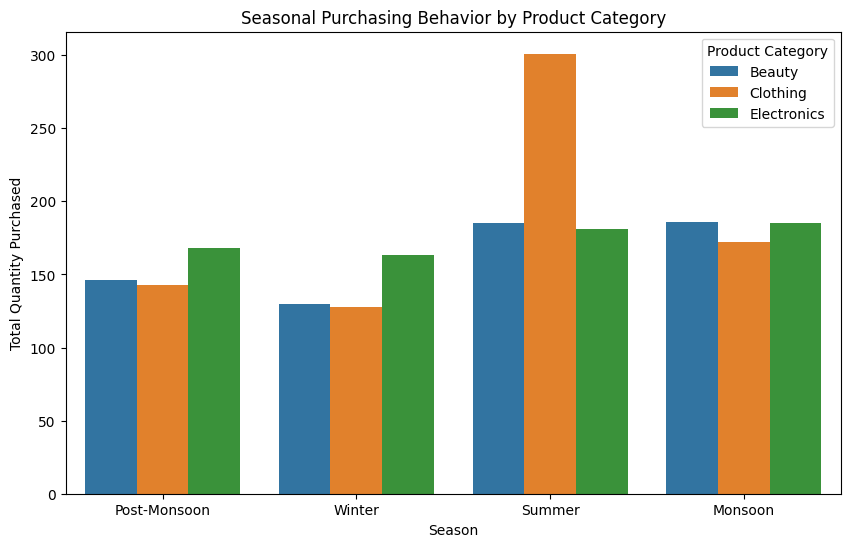

In [31]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x="Season", y="Quantity", estimator=sum,
            hue="Product Category", ci=False)
plt.title("Seasonal Purchasing Behavior by Product Category")
plt.ylabel("Total Quantity Purchased")
plt.show()

In [32]:
### Analyze the impact of quality

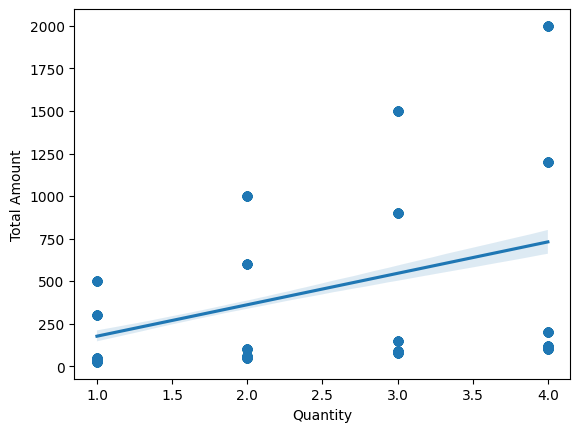

In [33]:
sns.regplot(data=df, x='Quantity', y='Total Amount')
plt.show()


Average Total Spending for each quantity level:
   Quantity  Total Amount
0         1    177.094862
1         2    333.539095
2         3    598.692946
3         4    706.692015


C:\Users\Sakshi Gangawane\AppData\Local\Temp\ipykernel_1216\2180441005.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=quantity_summary,x="Quantity",y="Total Amount",palette="viridis")


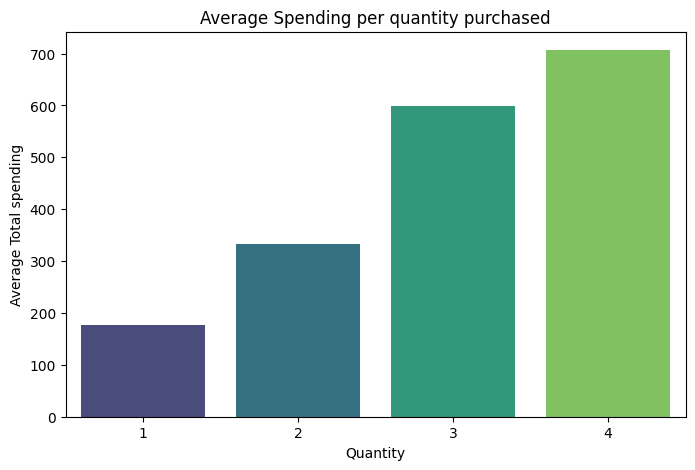

In [34]:
#3 Average spending based on Quantity 
quantity_summary = df.groupby("Quantity")['Total Amount'].mean().reset_index()
print("\nAverage Total Spending for each quantity level:")
print(quantity_summary)
plt.figure(figsize=(8,5))
sns.barplot(data=quantity_summary,x="Quantity",y="Total Amount",palette="viridis")
plt.title("Average Spending per quantity purchased")
plt.ylabel("Average Total spending")
plt.show()

### Identify the changes in product preferences over time 


##### A.count of each product category per month


In [35]:
monthly_counts=df.groupby(['Month', 'Product Category']).size().reset_index(name='Count')
monthly_counts

C:\Users\Sakshi Gangawane\AppData\Local\Temp\ipykernel_1216\2326922130.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_counts=df.groupby(['Month', 'Product Category']).size().reset_index(name='Count')


,Month,Product Category,Count
0,january,Beauty,0
1,january,Clothing,0
2,january,Electronics,0
3,February,Beauty,26
4,February,Clothing,33
5,February,Electronics,26
6,March,Beauty,21
7,March,Clothing,38
8,March,Electronics,14
9,April,Beauty,29


In [36]:
#sort months in proper order 
month_order=['january','February','March','April','May','June','July','Agust','September','October','November','December']

df['Month']=pd.Categorical(df['Month'],categories=month_order,ordered=True)
monthly_counts=monthly_counts.sort_values('Month')
monthly_counts

,Month,Product Category,Count
0,january,Beauty,0
1,january,Clothing,0
2,january,Electronics,0
3,February,Beauty,26
4,February,Clothing,33
5,February,Electronics,26
6,March,Beauty,21
7,March,Clothing,38
8,March,Electronics,14
9,April,Beauty,29


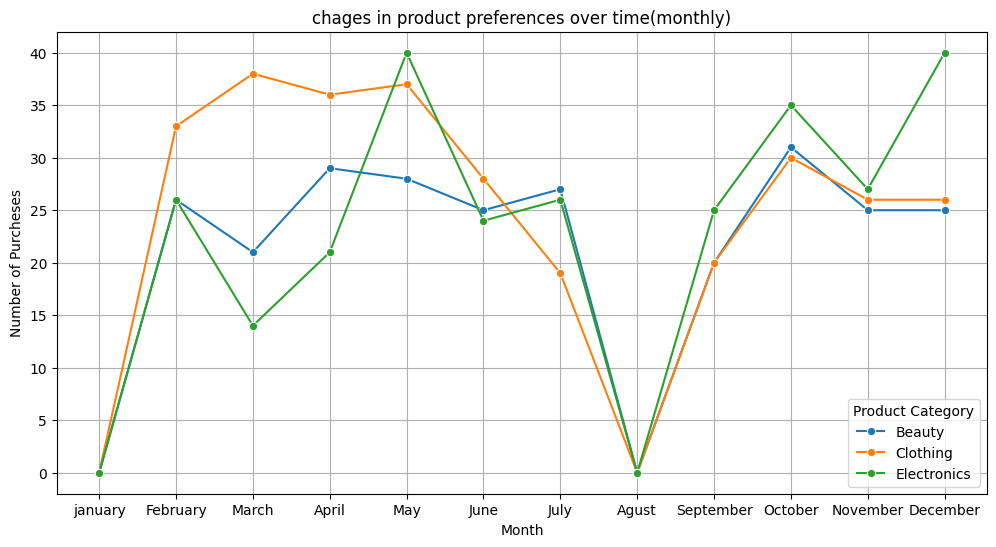

In [37]:
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_counts,x='Month', y='Count',hue='Product Category',marker="o")

#sns.barplot(data=monthly_counts,x='Month', y='Count',hue='Product Category')
plt.title("chages in product preferences over time(monthly)")
plt.xlabel("Month")
plt.ylabel("Number of Purcheses")
#plt.xticks(rotation=45)
plt.grid(True)
plt.show()
          

#### Year wise preference analysis

In [42]:
df['Year'].unique()
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Year,Days,MonthDate,age_group,Season,Revenue
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,2023,Friday,24,30-39,Post-Monsoon,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,2023,Monday,27,18-29,Winter,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,NaN,2023,Friday,13,40-49,NaN,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,2023,Sunday,21,30-39,Summer,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,2023,Saturday,6,18-29,Summer,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,May,2023,Tuesday,16,60+,Summer,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,November,2023,Friday,17,50-59,Post-Monsoon,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,October,2023,Sunday,29,18-29,Post-Monsoon,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,December,2023,Tuesday,5,30-39,Winter,150


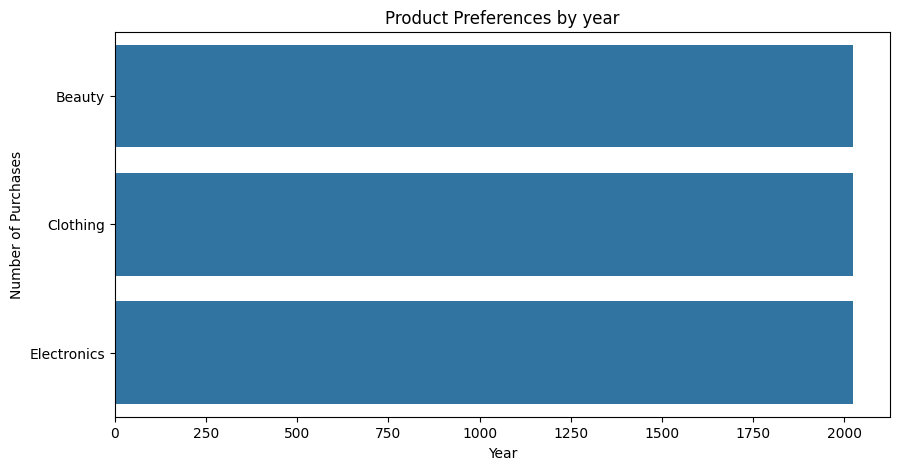

In [43]:
season_counts=df.groupby(['Year', 'Product Category']).size().reset_index()
#season_counts

plt.figure(figsize=(10,5))
sns.barplot(data=season_counts,x='Year', y= 'Product Category')
plt.title("Product Preferences by year")
plt.ylabel("Number of Purchases")
plt.show()

In [ ]:
#### identify customer groups that only buy in bulk vs. small quantities

In [44]:
df['qty_status']=df["Quantity"].apply(lambda x:'bulk quantities' if x in [3,4] else 'small quantities')
df['qty_status']

0       bulk quantities
1      small quantities
2      small quantities
3      small quantities
4      small quantities
             ...       
995    small quantities
996     bulk quantities
997     bulk quantities
998     bulk quantities
999     bulk quantities
Name: qty_status, Length: 1000, dtype: object

In [45]:
df['qty_status'].value_counts()

qty_status
bulk quantities     504
small quantities    496
Name: count, dtype: int64

In [46]:
df.groupby(['age_group', 'qty_status'])['qty_status'].count()

C:\Users\Sakshi Gangawane\AppData\Local\Temp\ipykernel_1216\2616223537.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['age_group', 'qty_status'])['qty_status'].count()


age_group  qty_status      
18-29      bulk quantities     128
           small quantities    124
30-39      bulk quantities     106
           small quantities     87
40-49      bulk quantities     106
           small quantities    115
50-59      bulk quantities     111
           small quantities    109
60+        bulk quantities      41
           small quantities     52
Name: qty_status, dtype: int64

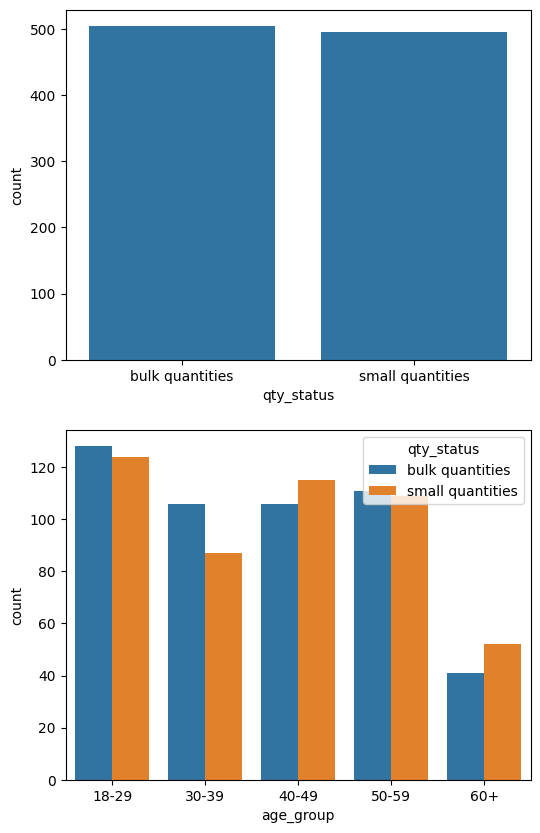

In [47]:
fig, axes = plt.subplots(nrows=2, ncols=1,figsize=(6,10))

sns.countplot(data = df,x='qty_status',ax=axes[0])

sns.countplot(data = df,x='age_group',hue = 'qty_status',ax=axes[1])

plt.show()

### Evaluate the price distribution within each product category.

In [48]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount',
       'Month', 'Year', 'Days', 'MonthDate', 'age_group', 'Season', 'Revenue',
       'qty_status'],
      dtype='object')

In [49]:
price_stats= df.groupby("Product Category")["Price per Unit"].describe()
print(price_stats)

                  count        mean         std   min   25%   50%    75%  \
Product Category                                                           
Beauty            307.0  184.055375  194.929399  25.0  30.0  50.0  300.0   
Clothing          351.0  174.287749  186.017065  25.0  30.0  50.0  300.0   
Electronics       342.0  181.900585  189.049673  25.0  30.0  50.0  300.0   

                    max  
Product Category         
Beauty            500.0  
Clothing          500.0  
Electronics       500.0  


C:\Users\Sakshi Gangawane\AppData\Local\Temp\ipykernel_1216\3437272511.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Price per Unit', y='Product Category',palette='viridis')


<Axes: xlabel='Price per Unit', ylabel='Product Category'>

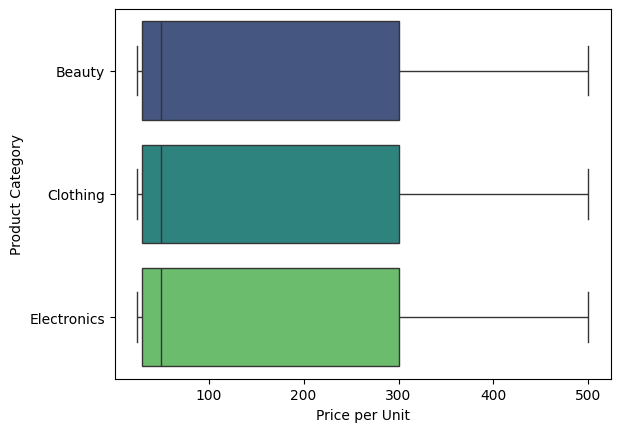

In [50]:
sns.boxplot(data=df, x='Price per Unit', y='Product Category',palette='viridis')

In [51]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount',
       'Month', 'Year', 'Days', 'MonthDate', 'age_group', 'Season', 'Revenue',
       'qty_status'],
      dtype='object')

In [52]:
df["Price per Unit"].unique()

array([ 50, 500,  30,  25, 300])

In [53]:
df["Price_flag"] = df["Price per Unit"].apply(lambda x:"premium_product" if x in [500,300] else "price_sensitive")
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Year,Days,MonthDate,age_group,Season,Revenue,qty_status,Price_flag
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,2023,Friday,24,30-39,Post-Monsoon,150,bulk quantities,price_sensitive
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,2023,Monday,27,18-29,Winter,1000,small quantities,premium_product
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,NaN,2023,Friday,13,40-49,NaN,30,small quantities,price_sensitive
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,2023,Sunday,21,30-39,Summer,500,small quantities,premium_product
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,2023,Saturday,6,18-29,Summer,100,small quantities,price_sensitive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,May,2023,Tuesday,16,60+,Summer,50,small quantities,price_sensitive
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,November,2023,Friday,17,50-59,Post-Monsoon,90,bulk quantities,price_sensitive
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,October,2023,Sunday,29,18-29,Post-Monsoon,100,bulk quantities,price_sensitive
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,December,2023,Tuesday,5,30-39,Winter,150,bulk quantities,price_sensitive


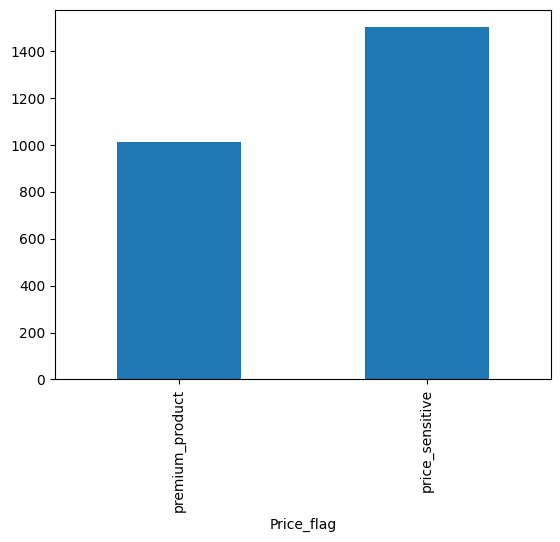

In [54]:
d=df.groupby("Price_flag")['Quantity'].sum().plot(kind="bar")
          

<function matplotlib.pyplot.show(close=None, block=None)>

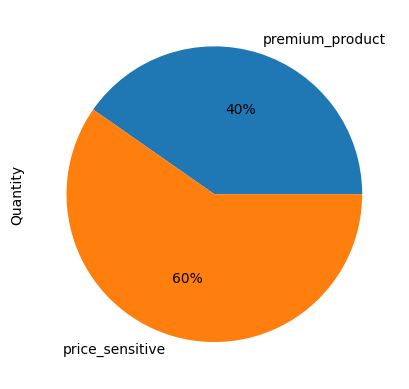

In [55]:
df.groupby("Price_flag")['Quantity'].sum().plot(kind="pie", autopct='%1.0f%%')
plt.show

### Identify high-value segments by demografics

In [56]:
Cust_id= (df.groupby("Customer ID")["Total Amount"].sum()
          .reset_index()
         )
Cust_id

,Customer ID,Total Amount
0,CUST001,150
1,CUST002,1000
2,CUST003,30
3,CUST004,500
4,CUST005,100
...,...,...
995,CUST995,30
996,CUST996,50
997,CUST997,90
998,CUST998,100


In [57]:
df_merged =df.merge(Cust_id, on="Customer ID",how='left')
df_merged

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount_x,Month,Year,Days,MonthDate,age_group,Season,Revenue,qty_status,Price_flag,Total Amount_y
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,2023,Friday,24,30-39,Post-Monsoon,150,bulk quantities,price_sensitive,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,2023,Monday,27,18-29,Winter,1000,small quantities,premium_product,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,NaN,2023,Friday,13,40-49,NaN,30,small quantities,price_sensitive,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,2023,Sunday,21,30-39,Summer,500,small quantities,premium_product,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,2023,Saturday,6,18-29,Summer,100,small quantities,price_sensitive,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,May,2023,Tuesday,16,60+,Summer,50,small quantities,price_sensitive,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,November,2023,Friday,17,50-59,Post-Monsoon,90,bulk quantities,price_sensitive,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,October,2023,Sunday,29,18-29,Post-Monsoon,100,bulk quantities,price_sensitive,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,December,2023,Tuesday,5,30-39,Winter,150,bulk quantities,price_sensitive,150


In [58]:
segment_spending = df_merged.groupby(["age_group", "Gender"])["Total Amount_y"].mean().reset_index()
print("\nAverage spending per segment:")
print(segment_spending)


Average spending per segment:
  age_group  Gender  Total Amount_y
0     18-29  Female      491.031746
1     18-29    Male      475.079365
2     30-39  Female      521.546392
3     30-39    Male      472.500000
4     40-49  Female      387.715517
5     40-49    Male      464.952381
6     50-59  Female      465.818966
7     50-59    Male      442.788462
8       60+  Female      319.761905
9       60+    Male      388.137255


C:\Users\Sakshi Gangawane\AppData\Local\Temp\ipykernel_1216\2712581179.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_spending = df_merged.groupby(["age_group", "Gender"])["Total Amount_y"].mean().reset_index()


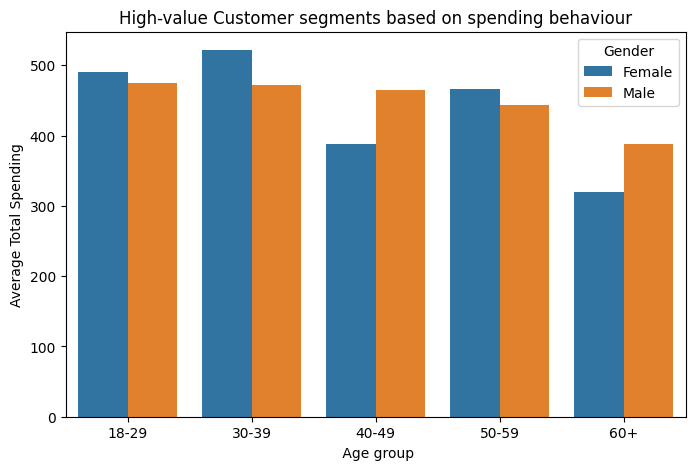

In [59]:
# visualize high- value segments
plt.figure(figsize=(8,5))
sns.barplot(data=segment_spending, x="age_group", y="Total Amount_y", hue="Gender")
plt.title("High-value Customer segments based on spending behaviour")
plt.xlabel(" Age group")
plt.ylabel("Average Total Spending")
plt.show()

In [60]:
#B.Identify product-category-based high-value segments

category_segment = df.groupby(["age_group", "Product Category"])["Total Amount"].sum().reset_index()
category_segment 

C:\Users\Sakshi Gangawane\AppData\Local\Temp\ipykernel_1216\2395497821.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_segment = df.groupby(["age_group", "Product Category"])["Total Amount"].sum().reset_index()


,age_group,Product Category,Total Amount
0,18-29,Beauty,40750
1,18-29,Clothing,44585
2,18-29,Electronics,36395
3,30-39,Beauty,32825
4,30-39,Clothing,31250
5,30-39,Electronics,31875
6,40-49,Beauty,33095
7,40-49,Clothing,29540
8,40-49,Electronics,31160
9,50-59,Beauty,26835


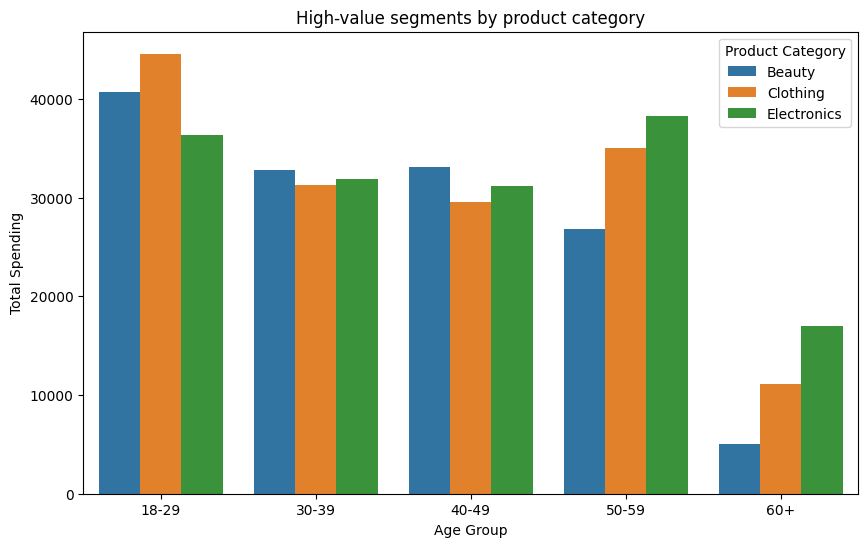

In [61]:
plt.figure(figsize=(10,6))
sns.barplot(data=category_segment, x="age_group", y="Total Amount", hue="Product Category")
plt.title("High-value segments by product category")
plt.ylabel("Total Spending")
plt.xlabel("Age Group")
plt.show()